In [1]:
print("lets do thiss....")

lets do thiss....


In [1]:
import os
from dotenv import load_dotenv
load_dotenv()


os.environ["GOOGLE_API_KEY"]=os.getenv("GOOGLE_API_KEY")


In [7]:
import os
from langchain.chat_models import init_chat_model

os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")

model = init_chat_model("google_genai:gemini-2.5-flash")
response = model.invoke("Why do parrots talk?")
response.content

'Parrots are fascinating creatures, and their ability to "talk" is a marvel of the animal kingdom. However, it\'s important to understand that they don\'t talk in the same way humans do, using language with grammar and syntax. Instead, they are incredible **mimics** and **vocal learners**.\n\nHere\'s a breakdown of why parrots talk:\n\n1.  **Social Connection and Bonding:**\n    *   **Flock Animals:** Parrots are highly social animals that live in large flocks in the wild. Vocalizations are crucial for maintaining flock cohesion, identifying individuals, warning of predators, and communicating about food sources.\n    *   **Integration:** When a parrot lives with humans, it views its human companions as its "flock." By mimicking human speech and other sounds, the parrot is attempting to communicate, bond, and integrate into its perceived social group. It\'s their way of trying to fit in and interact.\n    *   **Attention:** Parrots quickly learn that making human sounds often gets them

In [15]:
import os
from langchain.chat_models import init_chat_model

os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
import os

api_key = os.getenv("GOOGLE_API_KEY")

if api_key:
    print("API key loaded successfully")
else:
    print("API key not found")

model = init_chat_model(
    "gemini-2.0-flash", # Note: use current stable names
    model_provider="google_genai",
    api_key=os.environ["GOOGLE_API_KEY"]
)

response = model.invoke("Hello how are you")
print(response.content)

API key loaded successfully


ChatGoogleGenerativeAIError: Error calling model 'gemini-2.0-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\nPlease retry in 23.084069897s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url

In [6]:
response.content

"Hello! I'm doing great, thank you for asking.\n\nHow are you doing today? And how can I help you?"

# streaming
streaming is nothing but when we use respone = model.invoke it waits for the entire output to be generated then posts the ouput to the user but in streaming it does not wait for the entire outoupt instead it generates output as soon as it generates answer line by line does not wait for the entire outupt window to load



In [7]:
for chunk in model.stream("write me a detailed view on Napeolen bonaporte about 500 passatges"):
    print(chunk.text,end = "|",flush=True)

Napoleon Bonaparte remains one of history's most captivating and polarizing figures, a man whose meteoric rise| from obscure Corsican origins to Emperor of the French indelibly stamped his mark on Europe and the world. His legacy is a complex tapestry woven with threads of military genius, radical reform, boundless ambition, and devastating war, making him a perpetual| subject of debate, reverence, and condemnation.

At the heart of Napoleon's legend lies his unparalleled military genius. A master of strategy and tactics, he revolutionized warfare through his innovative use of artillery, rapid troop movements, and the concentration| of force, inspiring an almost fanatical loyalty in his soldiers. From the Italian campaigns to Austerlitz, Jena, and Wagram, his victories reshaped the military landscape, demonstrating a strategic mind that seemed to see several moves ahead of his opponents|. He was not merely a general but a battlefield artist, orchestrating his forces with a precision th

# batch
as the name goes it handles a huge number of input as output

In [ ]:
responses = model.batch(["how did python overthrow java ? now everyone says python this python that",
                         "is go language going to dominate Python any time?",
                         "what is git controles"])
for response in responses:
    print(response)

content='The idea that Python "overthrew" Java is a common perception, but it\'s more nuanced than a direct dethroning. It\'s more accurate to say that Python rose to prominence by excelling in new and rapidly growing domains where Java was less suited, while Java continues to be a dominant force in its traditional strongholds.\n\nHere\'s a breakdown of how Python gained so much traction and why it feels like "everyone says Python this Python that":\n\n### Python\'s Ascent: Key Factors\n\n1.  **The Rise of Data Science, Machine Learning, and AI:**\n    *   This is arguably the **single biggest factor**. Python developed an unparalleled ecosystem of libraries (NumPy, Pandas, SciPy, Scikit-learn, TensorFlow, PyTorch, Keras) that made it the de facto language for data analysis, machine learning, and artificial intelligence. Java simply doesn\'t have a comparable, user-friendly, and comprehensive suite of tools for these tasks.\n    *   The conciseness and interactivity of Python (especial

: 

now in batching we can configure how many batch of question can be passed that is what has been done below


In [10]:
responses = model.batch(["how did python overthrow java ? now everyone says python this python that",
                         "is go language going to dominate Python any time?",
                         "what is git controles"],
                         config={'max_concurrency':3,})
for response in responses:
    print(response)

content='That\'s a great observation, and you\'re right – Python has seen an incredible surge in popularity, leading many to feel like it\'s "overtaken" or "overthrown" Java. However, it\'s more accurate to say that **Python has found its dominant niches and expanded its influence significantly, rather than completely replacing Java.** Java is still a powerhouse in many areas.\n\nHere\'s a breakdown of how Python gained so much traction and why it feels like it\'s everywhere now:\n\n### Python\'s Rise: The "Why Python Now?"\n\n1.  **The Data Science and Machine Learning Boom (The Biggest Factor):**\n    *   **Ease of Use for Complex Math:** Python\'s simple syntax makes it ideal for researchers and data scientists who might not be career software engineers. They can focus on algorithms and data rather than complex language constructs.\n    *   **Mature Libraries:** The Python ecosystem boasts incredibly powerful and user-friendly libraries like NumPy (numerical computing), Pandas (data

# model with tools training
the name imples what it shows there are 2 ways 1 and 2 
work with 2 for better understanding


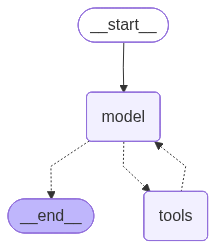

In [8]:
from langchain.agents import create_agent

def get_weather(city:str)-> str:
    """Get the weather for a city."""
    return f"The weather in {city} is sunny."

agent=create_agent(
    model = init_chat_model("google_genai:gemini-2.5-flash"),
    tools=[get_weather],
    system_prompt="You are a helpful assistant."
)
agent

In [9]:
from langchain.tools import tool
@tool
def get_weather(location:str):
    """get the weather at a location"""# this doc string is important as the llm would go through thsi doc string to understand the tool
    return f"the weather at {location} is sunny"
model_with_tools = model.bind_tools([get_weather])

In [8]:
response = model_with_tools.invoke("What's the weather like in Boston?")
print(response)
for tool_call in response.tool_calls:
    # View tool calls made by the model
    print(f"Tool: {tool_call['name']}")
    print(f"Args: {tool_call['args']}")

NameError: name 'model_with_tools' is not defined

In [11]:
# Step 1: Model generates tool calls
messages = [{"role": "user", "content": "What's the weather in Boston?"}]
ai_msg = model_with_tools.invoke(messages)
messages.append(ai_msg)

# Step 2: Execute tools and collect results
for tool_call in ai_msg.tool_calls:
    # Execute the tool with the generated arguments
    tool_result = get_weather.invoke(tool_call)
    messages.append(tool_result)

# Step 3: Pass results back to model for final response
final_response = model_with_tools.invoke(messages)
print(final_response.text)
# "The current weather in Boston is 72°F and sunny."

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 26.903450634s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeT